In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
from tqdm import tqdm 
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.lib import grdevices
from IPython.display import Image, display
import rpy2.robjects.packages as pkgs
from statsmodels.stats.multitest import multipletests
from itertools import product
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator
import os

def display_r_plot(plot):
    with grdevices.render_to_bytesio(grdevices.png, width=512, height=512, res=72) as img:
        ro.r.print(plot)
        
    img.seek(0)
    image = Image(data=img.read(), format='png')
    display(image)
    return image

pandas2ri.activate()
pkgs.importr('dplyr')
pkgs.importr('car')
pkgs.importr('effectsize')
pkgs.importr('emmeans')
pkgs.importr('lmerTest')
pkgs.importr('tidyr')
pkgs.importr('ggplot2')
pkgs.importr('performance')
pkgs.importr('nlme')
pkgs.importr('report')
pkgs.importr('modelbased')

rpy2.robjects.packages.Package as a <module 'modelbased'>

In [33]:
DATA_ROOT = 'Experiment/ParticipantData/fNIRS/FilteredData/'
files = [f for f in os.listdir(DATA_ROOT) if f.endswith('.csv') and '_b.csv' not in f]

dfs = []
for f in files:
    sub_df = pd.read_csv(os.path.join(DATA_ROOT, f))
    sub_df['condition'] = f.split('_')[1]
    dfs.append(sub_df)
df = pd.concat(dfs, ignore_index=True)
df = df.drop(columns=['Unnamed: 0', 'trial_id', 'MARKER'])
df = df[['pid', 'condition', 'time'] + [k for k in df.keys() if k not in ['pid', 'condition', 'time']]]

df = df.melt(id_vars=['pid', 'condition', 'time'], var_name='SIDE_WLEN_MEAS', value_name='value')

df[['SIDE', 'WLEN', 'MEAS']] = df['SIDE_WLEN_MEAS'].str.split('_', expand=True)
df = df.drop(columns=['SIDE_WLEN_MEAS'])

df.condition.unique()

df['DOMAIN'] = df['condition'].str[0]
df['INTER'] = df['condition'].str[1:]
df = df.drop(columns=['condition'])

df = df[(df.WLEN == 'O') & (df.MEAS == 'DSI')].drop(columns=['WLEN', 'MEAS'])

# df = df.groupby(['pid', 'SIDE', 'DOMAIN', 'INTER']).mean(numeric_only=True).reset_index()
df

,pid,time,value,SIDE,DOMAIN,INTER
0,22,2024-09-27 22:19:47.281618176,1.317972,L,F,W
1,22,2024-09-27 22:19:47.346659840,1.324740,L,F,W
2,22,2024-09-27 22:19:47.410644992,1.332869,L,F,W
3,22,2024-09-27 22:19:47.471101184,1.342102,L,F,W
4,22,2024-09-27 22:19:47.553235968,1.352246,L,F,W
...,...,...,...,...,...,...
450875,14,2024-09-20 21:30:42.653758976,0.574864,R,F,P
450876,14,2024-09-20 21:30:42.722071808,0.537369,R,F,P
450877,14,2024-09-20 21:30:42.789837824,0.500480,R,F,P
450878,14,2024-09-20 21:30:42.854604032,0.464219,R,F,P


In [34]:
from tqdm import tqdm
from mne.time_frequency import psd_array_multitaper,  tfr_array_morlet
from scipy.integrate import simpson

# VERY LOW FREQUENCY OSCILLATIONS
# HIGHER VLFO -> lower prefrontal activation

def freq_transform(fnirs_data, fs=5.2084):
    # VERY LOW FREQUENCY OSCILLATIONS
    # 0.02 - 50seconds
    # 0.07 - 14seconds
    psds, freqs = psd_array_multitaper(fnirs_data, 
                                        sfreq=fs, fmin=0.02, fmax=0.07,
                                        adaptive=True, low_bias=True, normalization='length',
                                        max_iter=2000, verbose="Warning")

    return simpson(psds, dx=freqs[1] - freqs[0])

freq_df = df.groupby(['pid', 'SIDE', 'DOMAIN', 'INTER']).value.apply(freq_transform).rename('vlf').reset_index()
freq_df.vlf = np.log(freq_df.vlf)
freq_df

,pid,SIDE,DOMAIN,INTER,vlf
0,2,L,F,W,-1.248164
1,2,L,L,P,-0.559139
2,2,R,F,W,3.081275
3,2,R,L,P,4.179305
4,3,L,F,P,-2.353124
...,...,...,...,...,...
141,24,R,L,W,-0.373022
142,24,R,R,P,-0.104860
143,24,R,R,W,-0.097362
144,25,L,L,W,-1.329006


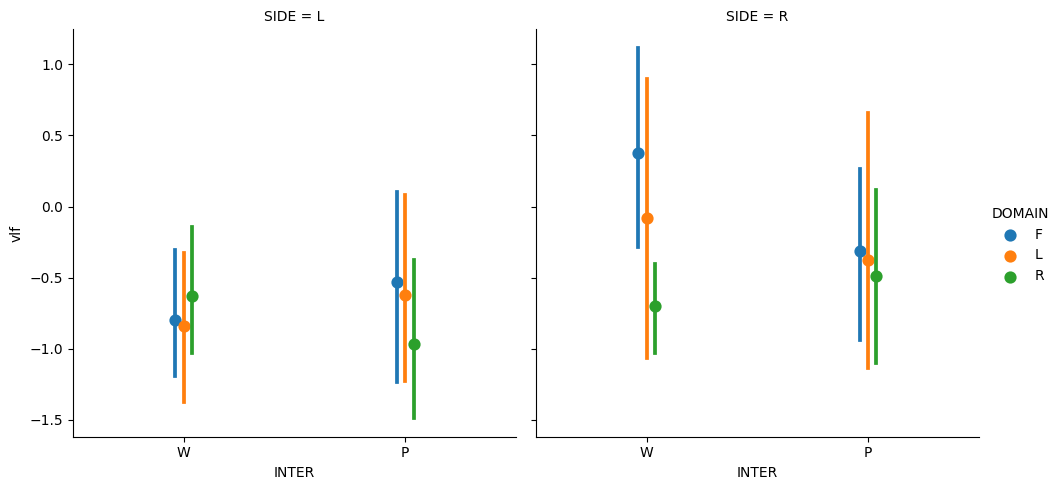

In [46]:
sns.catplot(kind='point', col='SIDE', data=freq_df, x='INTER', y='vlf', hue='DOMAIN', join=False, dodge=True)

<Axes: >

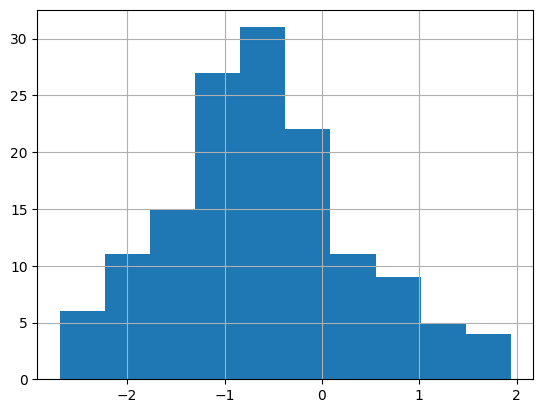

In [24]:
freq_df.vlf.hist()

R[write to console]: boundary (singular) fit: see help('isSingular')



Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: vlf ~ DOMAIN * INTER * SIDE + (1 + DOMAIN | pid)
   Data: df

REML criterion at convergence: 405.5

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.23196 -0.49871 -0.05446  0.39735  3.11384 

Random effects:
 Groups   Name        Variance Std.Dev. Corr       
 pid      (Intercept) 0.61109  0.7817              
          DOMAINL     0.07524  0.2743    1.00      
          DOMAINR     0.03473  0.1864   -1.00 -1.00
 Residual             0.71045  0.8429              
Number of obs: 146, groups:  pid, 23

Fixed effects:
                      Estimate Std. Error        df t value Pr(>|t|)  
(Intercept)           -0.50015    0.35286  80.31728  -1.417   0.1602  
DOMAINL                0.21182    0.42337 112.36453   0.500   0.6178  
DOMAINR               -0.44908    0.39613 110.58311  -1.134   0.2594  
INTERW                -0.52889    0.38626 111.05129  -1.369   0.1737  
SIDER    

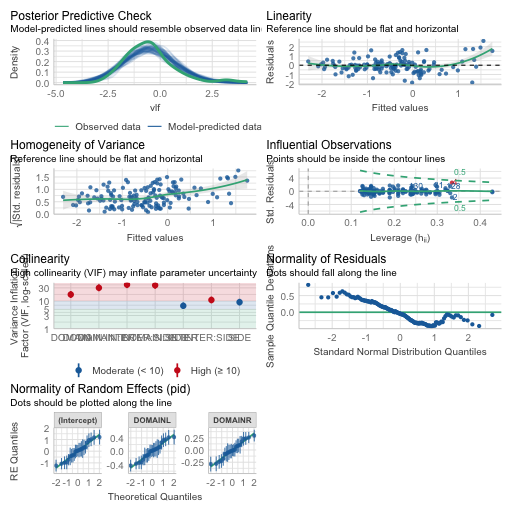

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
DOMAIN,2.561599,1.280799,2,57.886118,1.802793,0.173970
INTER,0.022520,0.022520,1,114.641458,0.031698,0.859006
SIDE,7.641285,7.641285,1,112.096932,10.755513,0.001386
DOMAIN:INTER,0.598752,0.299376,2,112.054460,0.421388,0.657171
DOMAIN:SIDE,1.478817,0.739408,2,112.096932,1.040757,0.356575
INTER:SIDE,0.832029,0.832029,1,112.096932,1.171124,0.281493
DOMAIN:INTER:SIDE,3.630086,1.815043,2,112.096932,2.554769,0.082228


In [52]:
r_func = ro.r('''
    function(df) {
        df$pid <- as.factor(df$pid)
        df$DOMAIN <- as.factor(df$DOMAIN)
        df$INTER <- as.factor(df$INTER)

        # linear mixed model
        m <- lmerTest::lmer(vlf ~ DOMAIN * INTER + (1+DOMAIN|pid), data=df)
       
        # linear model
        # m <- lm(vlf ~ DOMAIN * INTER, data=df)
        print(summary(m))

        ava <- anova(m) 
        chk_plot <- check_model(m)

        return (list(ava, chk_plot))

    }
''')
for side, side_df in freq_df.groupby('SIDE'):
    if side == 'L': 
        continue
    ava, chk_plot = r_func(side_df)
    display_r_plot(chk_plot)
    
    ava = ro.conversion.rpy2py(ava)
    display(ava)

In [ ]:
sns.catplot(kind='point', data=df, col='MEAS', row='SIDE', x='condition', hue='WLEN', y='value', join=False)